<a href="https://colab.research.google.com/github/anantc88/GenAI/blob/main/GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [4]:
# Read Excel file "Sales_Data" from sheet "sheet1"
df = pd.read_excel("Sales_Data.xlsx", sheet_name="Sheet1")
df
# Quick inspection
print(df.head())
print(df.info())

   quantity   price  experience engineer  gender  location  budget_agency  \
0       499  261.52           5       No       0         7            839   
1       439  288.30           6       No       0        13           1410   
2       355  310.35           3      Yes       0        12           1043   
3       513  253.91           4       No       0        11            765   
4       413  307.83           6       No       0        14           1564   

   budget_phone  budget_social_media  
0           399                  440  
1           706                  704  
2           525                  518  
3           386                  379  
4           785                  779  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity             100 non-null    int64  
 1   price                100 non-null    float64


gender_label
Male      64
Female    36
Name: count, dtype: int64


/tmp/ipython-input-3917887254.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gender_label', data=df, palette='pastel', order=counts.index)


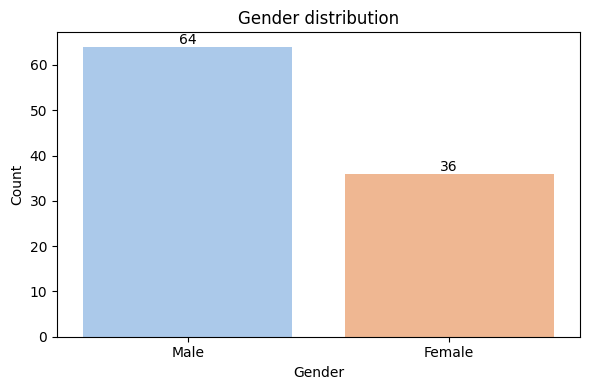

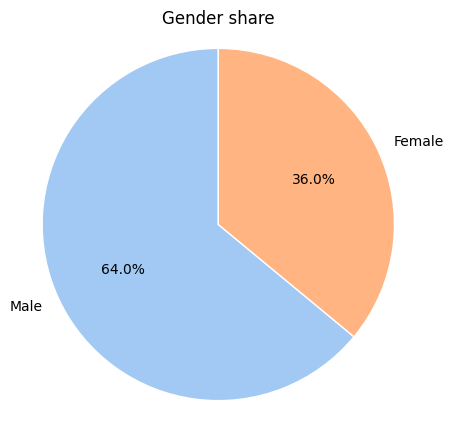

In [6]:
#############
# Map numeric codes to labels and get counts
df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})
counts = df['gender_label'].value_counts(dropna=False)
print(counts)
# Count plot (bar)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='gender_label', data=df, palette='pastel', order=counts.index)
ax.set_title('Gender distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
# Pie chart (percentages)
plt.figure(figsize=(5,5))
colors = sns.color_palette('pastel')[:len(counts)]
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops=dict(edgecolor='w'))
plt.title('Gender share')
plt.axis('equal')
plt.show()


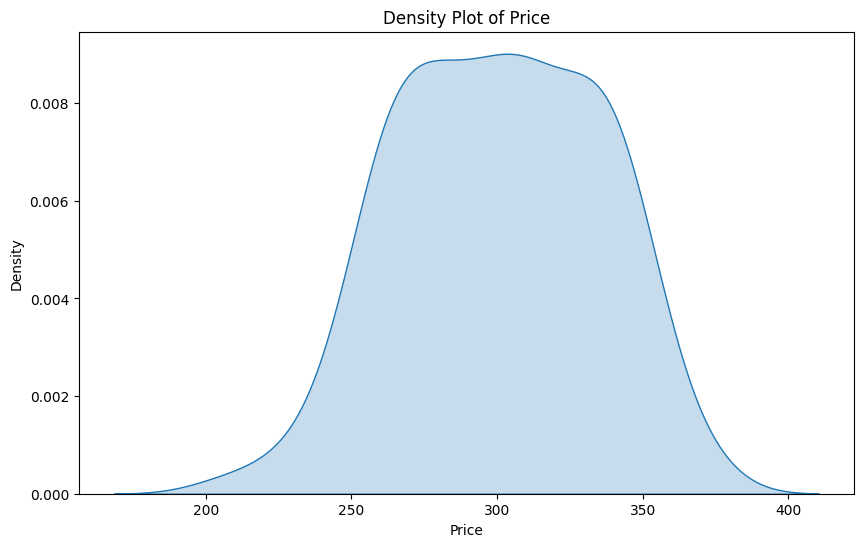

In [8]:
##################################################
##### Density plot for price
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price', fill=True)
plt.title('Density Plot of Price')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

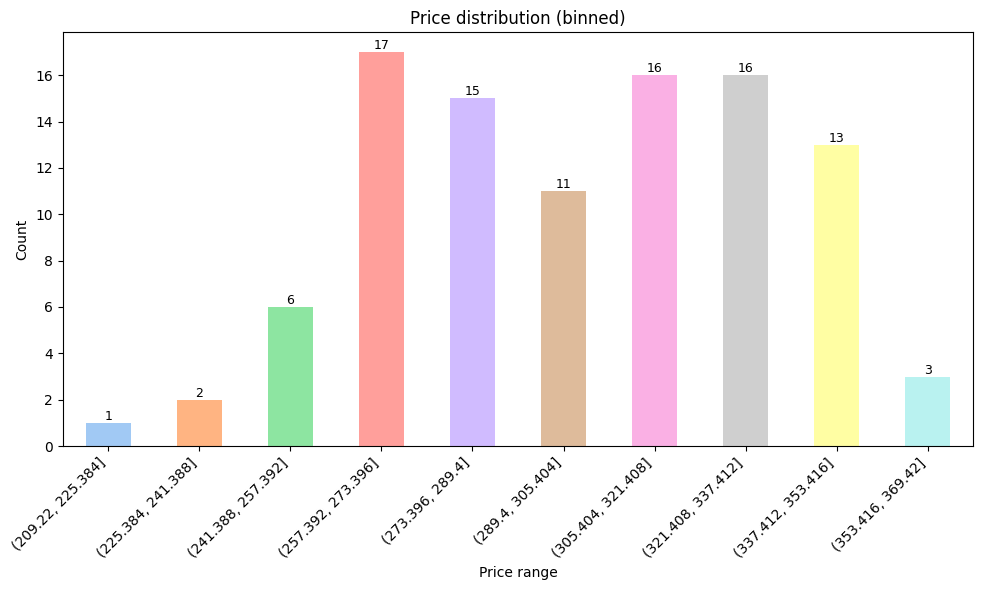

In [10]:
# Bar plot of price distribution (binned)
plt.figure(figsize=(10,6))
bins = 10  # adjust number of bins as needed
price_series = df['price'].dropna()
price_bins = pd.cut(price_series, bins=bins)
counts = price_bins.value_counts().sort_index()
ax = counts.plot(kind='bar', color=sns.color_palette('pastel', n_colors=bins))
ax.set_title('Price distribution (binned)')
ax.set_xlabel('Price range')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4264871738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=exp_filled, order=exp_counts.index, palette='pastel')


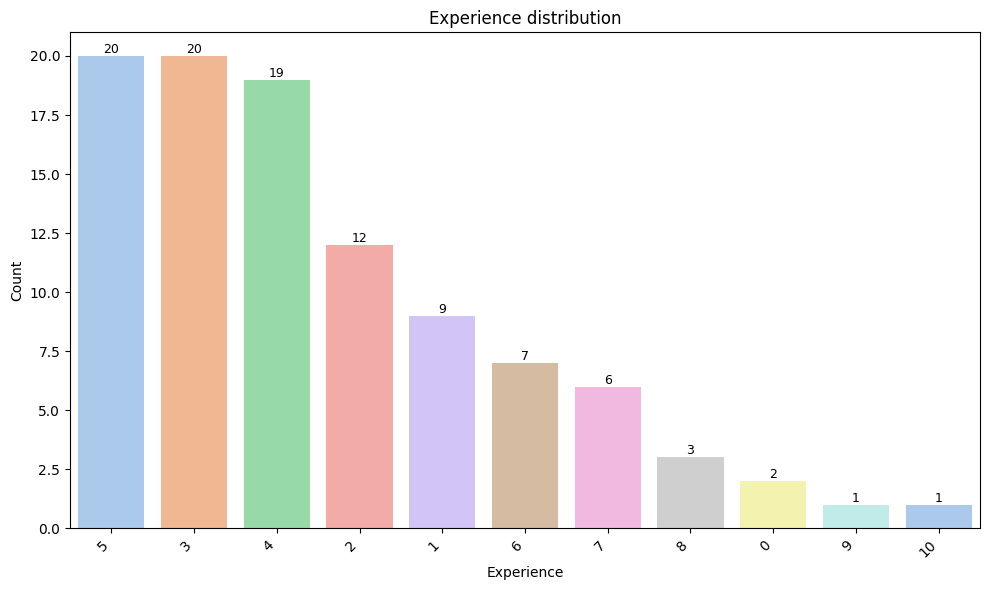

In [12]:
# Bar plot for 'experience'
plt.figure(figsize=(10,6))
exp_series = df['experience']
# If numeric with many unique values, bin; otherwise treat as categorical (including missing)
if pd.api.types.is_numeric_dtype(exp_series) and exp_series.nunique(dropna=True) > 15:
    bins = 10
    exp_binned = pd.cut(exp_series.dropna(), bins=bins)
    exp_counts = exp_binned.value_counts().sort_index()
    ax = exp_counts.plot(kind='bar', color=sns.color_palette('pastel', n_colors=len(exp_counts)))
    ax.set_xlabel('Experience (binned)')
else:
    exp_filled = exp_series.fillna('Missing').astype(str)
    exp_counts = exp_filled.value_counts()
    ax = sns.countplot(x=exp_filled, order=exp_counts.index, palette='pastel')
    ax.set_xlabel('Experience')
ax.set_title('Experience distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

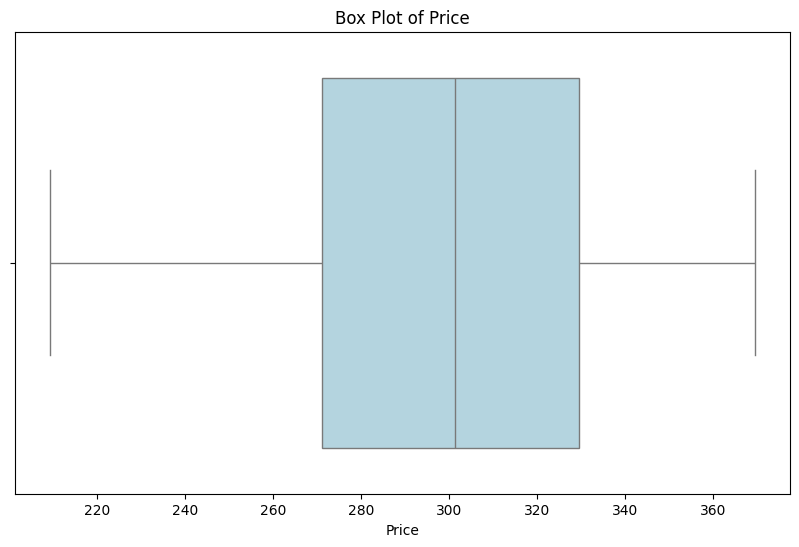

In [14]:
# Box plot for 'price'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='lightblue')
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

In [15]:
from scipy.stats import ttest_ind

In [17]:
#######
# Conducting a t-test between budget_phone and budget_social_media
t_stat, p_value = ttest_ind(df['budget_phone'].dropna(), df['budget_social_media'].dropna())
print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

T-statistic: 0.016122424481620573
P-value: 0.987152957692865


In [22]:
############################
###############
# Regression: quantity ~ price (numerical summary + visual summary)
import statsmodels.api as sm
from statsmodels.api.graphics import qqplot
# Prepare data (drop rows with missing price or quantity)
reg_df = df[['quantity', 'price']].dropna()
X = sm.add_constant(reg_df['price'])  # adds intercept
y = reg_df['quantity']
# Fit OLS model
model = sm.OLS(y, X).fit()
# 1) Numerical summary
print(model.summary())
# Also print a concise set of key metrics
print("\nCoefficients:")
print(model.params)
print("\nP-values:")
print(model.pvalues)
print(f"\nR-squared: {model.rsquared:.4f}")
# 2) Visual summary
# Scatter with regression line (with 95% CI)
plt.figure(figsize=(8,6))
ax = sns.scatterplot(x='price', y='quantity', data=reg_df, color='C0', s=50, alpha=0.7)
sns.regplot(x='price', y='quantity', data=reg_df, scatter=False, ci=95, line_kws={'color':'red'}, ax=ax)
ax.set_title('Quantity vs Price with OLS fit')
ax.set_xlabel('Price')
ax.set_ylabel('Quantity')
plt.tight_layout()
plt.show()
# Residuals vs Fitted
fitted = model.fittedvalues
residuals = model.resid
plt.figure(figsize=(8,6))
ax = sns.scatterplot(x=fitted, y=residuals, color='C1', s=50, alpha=0.7)
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
plt.tight_layout()
plt.show()
# QQ-plot of residuals
plt.figure(figsize=(6,6))
qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('QQ-plot of Residuals')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'statsmodels.api.graphics'; 'statsmodels.api' is not a package

In [21]:
!pip install statsmodels --upgrade